In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/software_quality_dataset.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1520 non-null   float64
 1   Cyclomatic_Complexity  1600 non-null   int64  
 2   Num_Functions          1600 non-null   int64  
 3   Code_Churn             1520 non-null   float64
 4   Comment_Density        1520 non-null   float64
 5   Num_Bugs               1600 non-null   int64  
 6   Has_Unit_Tests         1600 non-null   object 
 7   Code_Owner_Experience  1600 non-null   int64  
 8   Quality_Label          1600 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 112.6+ KB


,0
Lines_of_Code,80
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,80
Comment_Density,80
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0
Quality_Label,0


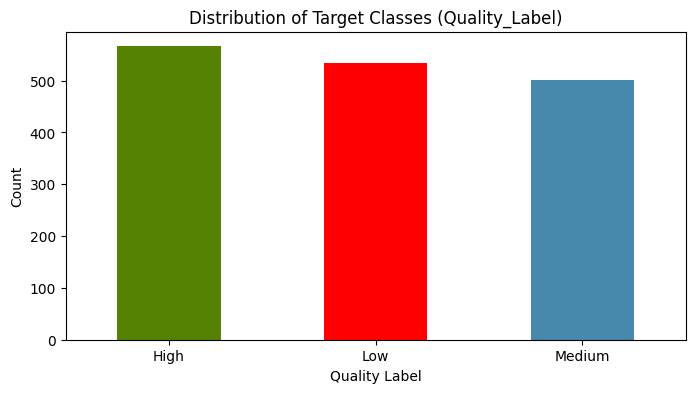

In [ ]:
plt.figure(figsize=(8, 4))
df['Quality_Label'].value_counts().plot(kind='bar', color=['#568203', '#FF0000', '#4689AC'])
plt.title('Distribution of Target Classes (Quality_Label)')
plt.xlabel('Quality Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

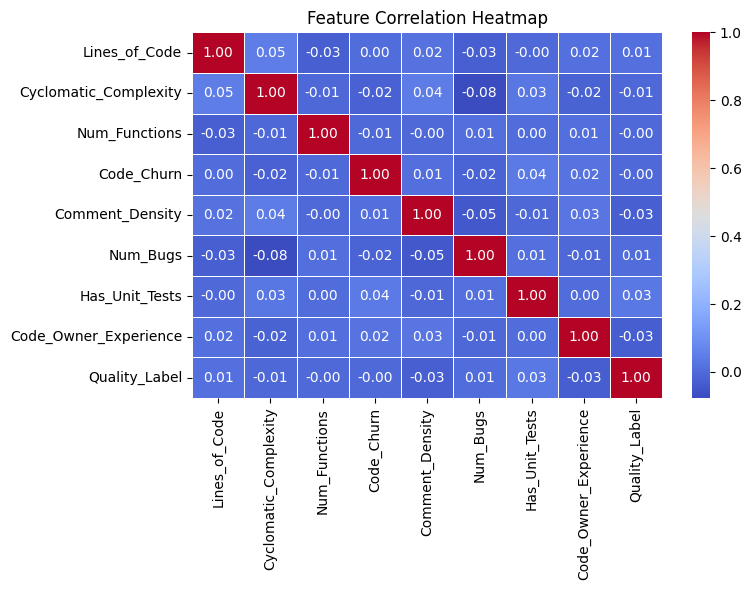

In [ ]:
df_corr = df.copy()
df_corr['Has_Unit_Tests'] = df_corr['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})
df_corr['Quality_Label'] = df_corr['Quality_Label'].map({'Low': 0, 'Medium': 1, 'High': 2})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

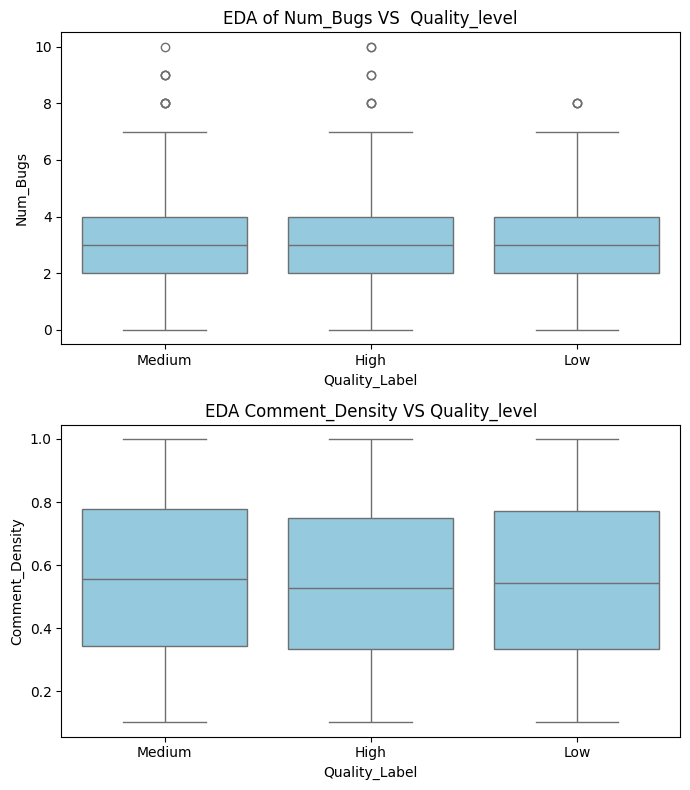

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

sns.boxplot(x='Quality_Label', y='Num_Bugs', data=df, ax=axes[0], color = 'skyblue')
axes[0].set_title('EDA of Num_Bugs VS  Quality_level')

sns.boxplot(x='Quality_Label', y='Comment_Density', data=df, ax=axes[1], color = 'skyblue')
axes[1].set_title('EDA Comment_Density VS Quality_level')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

cols_of_nan = ['Lines_of_Code', 'Code_Churn', 'Comment_Density']

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

df[cols_of_nan] = imputer.fit_transform(df[cols_of_nan])

df.isnull().sum()

,0
Lines_of_Code,0
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,0
Comment_Density,0
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0
Quality_Label,0


In [ ]:
df['Has_Unit_Tests'] = df['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})

from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df['Quality_Label_Encoded'] = enc.fit_transform(df['Quality_Label'])
print(enc.classes_)

['High' 'Low' 'Medium']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Quality_Label', 'Quality_Label_Encoded'])
y = df['Quality_Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=42)

clf.fit(X_train_scaled, y_train)
clf_pred = clf.predict(X_test_scaled)



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)
dt_pred = dt_clf.predict(X_test_scaled)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
mlp_clf.fit(X_train_scaled, y_train)
mlp_pred = mlp_clf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

print("Decision Tree:", accuracy_score(y_test, dt_pred) * 100 ,"%")
print("Logistic Regression:", accuracy_score(y_test, clf_pred) * 100,"%")
print("Neural Network:", accuracy_score(y_test, mlp_pred) * 100,"%")

Decision Tree: 34.6875 %
Logistic Regression: 32.5 %
Neural Network: 34.0625 %


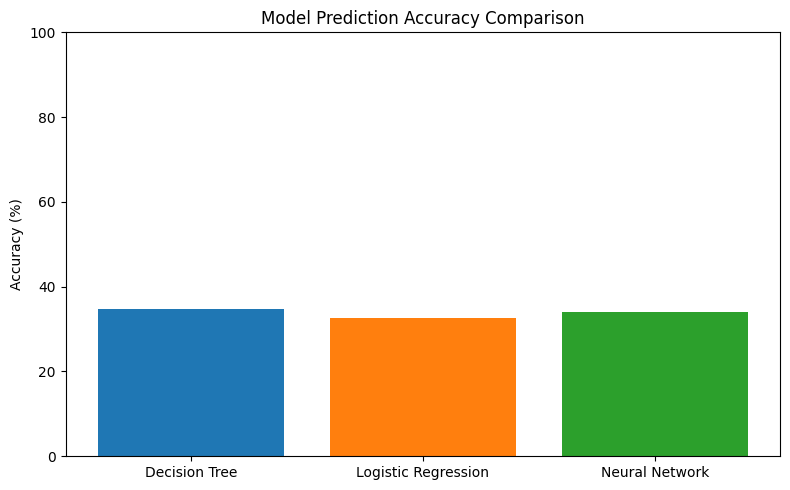

In [ ]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Logistic Regression', 'Neural Network']
accuracies = [
    accuracy_score(y_test, dt_pred) * 100,
    accuracy_score(y_test, clf_pred) * 100,
    accuracy_score(y_test, mlp_pred) * 100
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.ylabel('Accuracy (%)')
plt.title('Model Prediction Accuracy Comparison')
plt.ylim(0,100)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name, pred in zip(models, [dt_pred, clf_pred, mlp_pred]):
    print(f"- {name} -")
    print(classification_report(y_test, pred, target_names=enc.classes_))

- Decision Tree -
              precision    recall  f1-score   support

        High       0.33      0.36      0.34       113
         Low       0.37      0.37      0.37       107
      Medium       0.34      0.30      0.32       100

    accuracy                           0.35       320
   macro avg       0.35      0.35      0.35       320
weighted avg       0.35      0.35      0.35       320

- Logistic Regression -
              precision    recall  f1-score   support

        High       0.36      0.55      0.43       113
         Low       0.23      0.15      0.18       107
      Medium       0.34      0.26      0.29       100

    accuracy                           0.33       320
   macro avg       0.31      0.32      0.30       320
weighted avg       0.31      0.32      0.31       320

- Neural Network -
              precision    recall  f1-score   support

        High       0.37      0.45      0.41       113
         Low       0.35      0.26      0.30       107
      Medium  

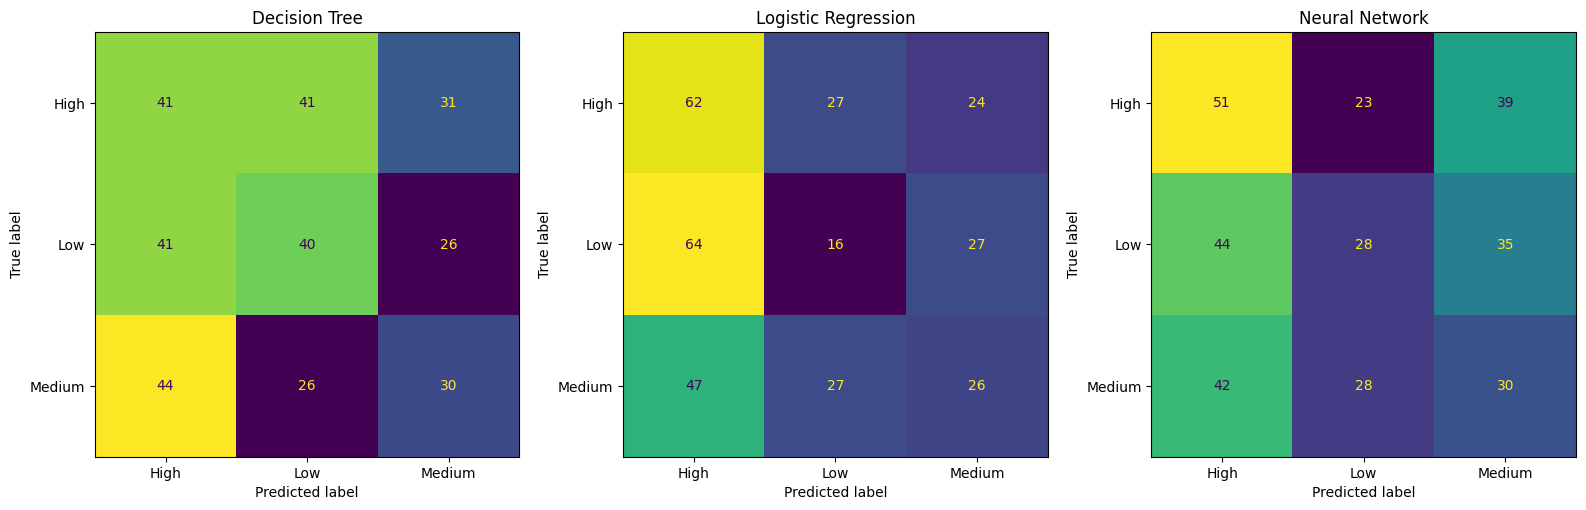

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16,5))
preds = [dt_pred, clf_pred, mlp_pred]

for ax, name, pred in zip(axes.flatten(), models, preds):
    conf_mat = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(conf_mat, display_labels=enc.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

models = ['Decision Tree', 'Logistic Regression', 'Neural Network']

for name, model in zip(models, [dt_clf, clf, mlp_clf]):
    prob = model.predict_proba(X_test_scaled)
    auc = roc_auc_score(y_test, prob, multi_class='ovr') * 100
    print(f"{name} AUC: {auc:.3f}%")

Decision Tree AUC: 50.873%
Logistic Regression AUC: 51.320%
Neural Network AUC: 51.862%


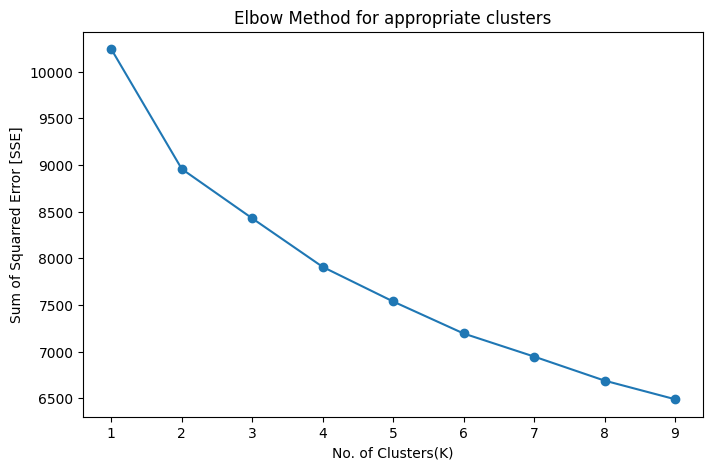

In [ ]:
from sklearn.cluster import KMeans
K_range = range(1, 10)
SSE = []
for k in K_range:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_means.fit(X_train_scaled)
    SSE.append(k_means.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, SSE, marker='o')
plt.xlabel('No. of Clusters(K)')
plt.ylabel('Sum of Squarred Error [SSE]')
plt.title('Elbow Method for appropriate clusters')
plt.show()


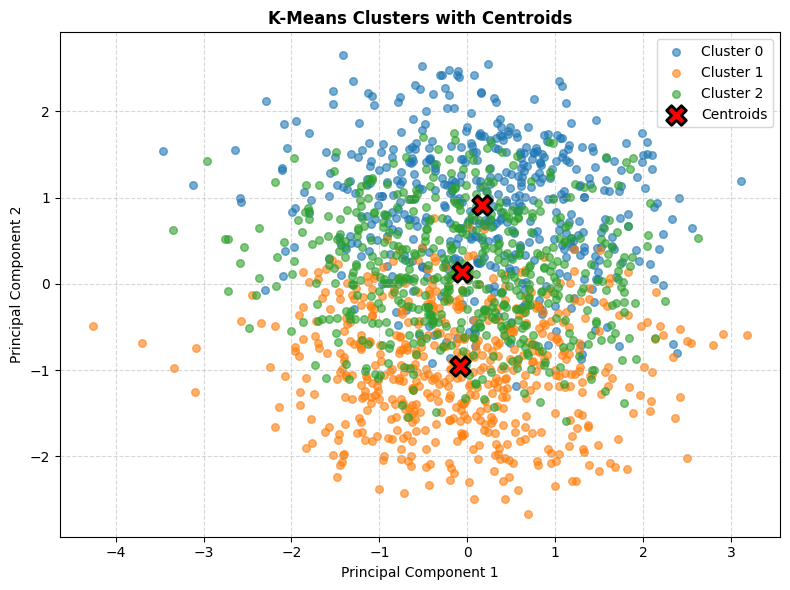

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = df.drop(columns=['Quality_Label'])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

K_means = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = K_means.fit_predict(X_train_scaled)
centroids = K_means.cluster_centers_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i in range(3):
    plt.scatter(X_pca[clusters == i, 0],X_pca[clusters == i, 1],c=colors[i],label=f'Cluster {i}',alpha=0.6,s=30)
plt.scatter(centroids_pca[:, 0],centroids_pca[:, 1],c='red',marker='X',s=200,linewidths=2,edgecolors='black',label='Centroids',zorder=10)
plt.title('K-Means Clusters with Centroids', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


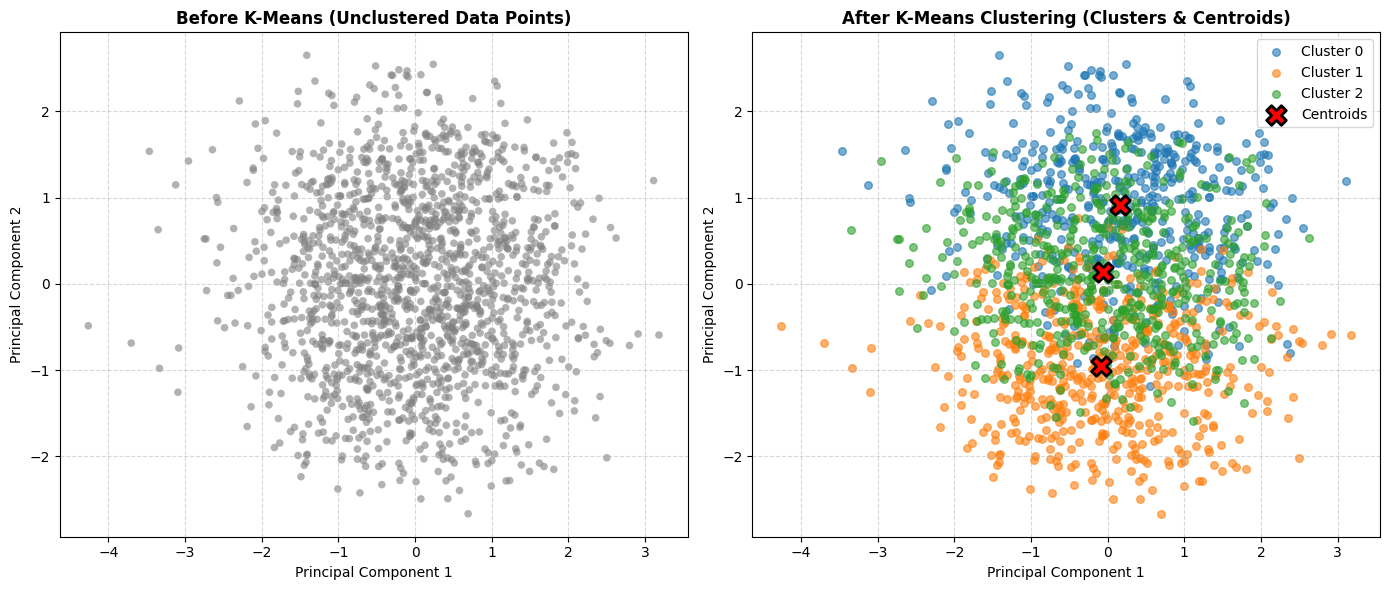

In [ ]:
X = df.drop(columns=['Quality_Label'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

K_means = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = K_means.fit_predict(X_train_scaled)
centroids = K_means.cluster_centers_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
centroids_pca = pca.transform(centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.6, s=30, edgecolors='none')
axes[0].set_title('Before K-Means (Unclustered Data Points)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
  axes[1].scatter(X_pca[clusters == i, 0],X_pca[clusters == i, 1],c=colors[i],label=f'Cluster {i}',alpha=0.6,s=30)

axes[1].scatter(centroids_pca[:, 0],centroids_pca[:, 1],c='red',marker='X',s=200,linewidths=2,edgecolors='black',label='Centroids',zorder=10)

axes[1].set_title('After K-Means Clustering (Clusters & Centroids)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()